# CCS3440 — Artificial Intelligence Coursework
## Disease Risk Classification (Option C)
### SmartCare Hospital AI Dataset

**Group:** FYP Group 04 "WHALES" (batch 2027A)
**Problem:** Classify patients into disease risk categories (Low / Medium / High).
**Target Variable:** `disease_risk_level` (Multi-Class Classification)

---


# Task 02 — Dataset Understanding

We load the SmartCare Hospital dataset and examine its structure, attributes, and data
quality before any preprocessing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('smartcare_ai_dataset_1000.csv')
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 1000 rows, 33 columns


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   str    
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   str    
 4   blood_group                   1000 non-null   str    
 5   department                    1000 non-null   str    
 6   diagnosis                     1000 non-null   str    
 7   appointment_date              1000 non-null   str    
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   str    
 12  admitted                      1000 non-null   int64  
 13  room_type      

### 2.1 Attribute Description

| Category | Attributes |
|---|---|
| Patient Info | `patient_id`, `age`, `gender`, `blood_group` |
| Clinical Info | `diagnosis`, `systolic_bp`, `diastolic_bp`, `blood_sugar_mg_dl`, `cholesterol_mg_dl`, `bmi` |
| Operations | `department`, `appointment_date`, `waiting_days`, `previous_appointments`, `missed_previous_appointments`, `appointment_status`, `admitted`, `room_type`, `length_of_stay_days`, `previous_admissions`, `lab_tests_count`, `treatments_count` |
| Financial | `consultation_fee_lkr`, `room_charge_lkr`, `lab_charge_lkr`, `medicine_charge_lkr`, `total_bill_lkr`, `payment_status`, `payment_method` |
| Targets | `no_show` (Option A), `readmitted_30_days` (Option B), `disease_risk_level` (Option C — **our target**) |

### 2.2 Target Variable Analysis

Unlike Option B (readmission), `disease_risk_level` has no missing values and applies to
every patient regardless of admission status — no population filtering is required here.


In [3]:
print("disease_risk_level distribution:")
print(df['disease_risk_level'].value_counts())
print()
print(df['disease_risk_level'].value_counts(normalize=True).round(3))
print()
print("Missing values in target:", df['disease_risk_level'].isnull().sum())

disease_risk_level distribution:
disease_risk_level
Medium    469
High      400
Low       131
Name: count, dtype: int64

disease_risk_level
Medium    0.469
High      0.400
Low       0.131
Name: proportion, dtype: float64

Missing values in target: 0


### 2.3 Data Quality Check

In [4]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSummary statistics (numeric):")
df.describe().T

Missing values:
room_type    906
dtype: int64

Duplicate rows: 0

Summary statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
record_id,1000.0,500.5000,288.819436,1.0,250.75,500.5,750.25,1000.0
age,1000.0,44.7440,17.851474,1.0,33.00,44.0,57.00,90.0
waiting_days,1000.0,21.8510,13.040892,0.0,11.00,22.0,34.00,44.0
previous_appointments,1000.0,2.8840,1.693343,0.0,2.00,3.0,4.00,10.0
missed_previous_appointments,1000.0,0.5530,0.740094,0.0,0.00,0.0,1.00,4.0
admitted,1000.0,0.3300,0.470448,0.0,0.00,0.0,1.00,1.0
length_of_stay_days,1000.0,1.1030,1.885191,0.0,0.00,0.0,2.00,9.0
previous_admissions,1000.0,0.8550,0.958590,0.0,0.00,1.0,1.00,5.0
systolic_bp,1000.0,128.4230,15.486895,85.0,117.00,128.0,139.00,178.0
diastolic_bp,1000.0,78.8280,10.043669,50.0,72.00,79.0,86.00,111.0


### 2.4 Sanity Check for Leakage

Before modelling, we confirm no column trivially determines the target (unlike Option B,
where `admitted` leaked into `readmitted_30_days`). We check whether clinical vitals scale
sensibly with risk level rather than a single column perfectly separating the classes.


In [5]:
df.groupby('disease_risk_level')[['systolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl','bmi','age']].mean().round(1)

,systolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,age
disease_risk_level,,,,,
High,134.2,128.7,222.5,27.2,55.4
Low,121.1,93.3,174.2,22.6,27.6
Medium,125.6,109.0,198.3,24.9,40.5


No single column perfectly separates the classes — average blood pressure, blood sugar,
cholesterol, BMI, and age all increase gradually from Low to Medium to High risk, which is
clinically sensible and gives multiple genuine predictive signals rather than one leaking
column. All 1000 records are used for modelling (no filtering needed).


---
# Task 03 — Data Preprocessing and Feature Engineering


### 3.1 Missing Value Handling

`room_type` is missing for the 670 non-admitted patients (only admitted patients are
assigned a room). Since we keep the full population for this task (unlike Option B), we
impute with an explicit **"Not Admitted"** category rather than a ward name, since that is
the true, meaningful reason for the missingness.


In [6]:
df_clean = df.copy()
print("room_type missing before imputation:", df_clean['room_type'].isnull().sum())
df_clean['room_type'] = df_clean['room_type'].fillna('Not Admitted')
print("room_type missing after imputation:", df_clean['room_type'].isnull().sum())

room_type missing before imputation: 906
room_type missing after imputation: 0


### 3.2 Duplicate Records

No duplicate rows were found (checked above).

### 3.3 Outlier Identification (IQR method)


In [7]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

check_cols = ['systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl','bmi',
              'length_of_stay_days','total_bill_lkr']
for c in check_cols:
    print(f"{c:25s} outliers: {iqr_outliers(df_clean[c])}")

systolic_bp               outliers: 3
diastolic_bp              outliers: 3
blood_sugar_mg_dl         outliers: 10
cholesterol_mg_dl         outliers: 6
bmi                       outliers: 9
length_of_stay_days       outliers: 48
total_bill_lkr            outliers: 59


Outliers are flagged but not removed — extreme clinical vitals (e.g. very high blood
sugar or cholesterol) are directly relevant to disease risk classification and are likely
genuine high-risk cases rather than data errors.

### 3.4 Feature Engineering


In [8]:
fe = df_clean.copy()

fe['bmi_category'] = pd.cut(fe['bmi'], bins=[0,18.5,25,30,100],
                             labels=['Underweight','Normal','Overweight','Obese'])
fe['age_group'] = pd.cut(fe['age'], bins=[0,18,35,50,65,120],
                          labels=['0-18','19-35','36-50','51-65','65+'])
fe['high_bp_flag'] = ((fe['systolic_bp'] >= 140) | (fe['diastolic_bp'] >= 90)).astype(int)
fe['high_sugar_flag'] = (fe['blood_sugar_mg_dl'] >= 126).astype(int)
fe['high_chol_flag'] = (fe['cholesterol_mg_dl'] >= 240).astype(int)
fe['prior_utilization'] = fe['previous_admissions'] + fe['previous_appointments']
fe['care_intensity'] = fe['lab_tests_count'] + fe['treatments_count']
fe['missed_appointment_rate'] = (fe['missed_previous_appointments'] /
                                  fe['previous_appointments'].replace(0, np.nan)).fillna(0)
# Composite clinical risk flag count — sums the three individual vital-sign flags
fe['risk_flag_count'] = fe['high_bp_flag'] + fe['high_sugar_flag'] + fe['high_chol_flag']

print("New engineered features added:")
print(['bmi_category','age_group','high_bp_flag','high_sugar_flag','high_chol_flag',
       'prior_utilization','care_intensity','missed_appointment_rate','risk_flag_count'])
fe[['bmi_category','age_group','risk_flag_count']].head()

New engineered features added:
['bmi_category', 'age_group', 'high_bp_flag', 'high_sugar_flag', 'high_chol_flag', 'prior_utilization', 'care_intensity', 'missed_appointment_rate', 'risk_flag_count']


,bmi_category,age_group,risk_flag_count
0,Overweight,51-65,0
1,Obese,19-35,1
2,Overweight,19-35,1
3,Normal,36-50,1
4,Overweight,51-65,0


### 3.5 Feature Selection

We drop identifiers, raw dates, and the alternative-option target columns (`no_show` for
Option A, `readmitted_30_days` for Option B) — these are not legitimate predictors for our
Option C task. We keep `admitted` this time (unlike Option B), since it is not constant
here and may carry genuine information about disease severity.


In [9]:
drop_cols = ['record_id','patient_id','appointment_date','no_show','readmitted_30_days']
model_df = fe.drop(columns=drop_cols)
print(f"Remaining columns for modelling: {model_df.shape[1]}")
print(model_df.columns.tolist())

Remaining columns for modelling: 37
['age', 'gender', 'blood_group', 'department', 'diagnosis', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'appointment_status', 'admitted', 'room_type', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr', 'payment_status', 'payment_method', 'disease_risk_level', 'bmi_category', 'age_group', 'high_bp_flag', 'high_sugar_flag', 'high_chol_flag', 'prior_utilization', 'care_intensity', 'missed_appointment_rate', 'risk_flag_count']


### 3.6 Encoding

`bmi_category` and `age_group` are ordinal-encoded. Nominal categorical columns are
one-hot encoded. The target `disease_risk_level` is label-encoded (Low=0, Medium=1, High=2)
for scikit-learn/XGBoost compatibility, preserving the clinical ordering.


In [10]:
from sklearn.preprocessing import LabelEncoder

target = 'disease_risk_level'
y_labels = model_df[target]
X = model_df.drop(columns=[target])

bmi_order = {'Underweight':0,'Normal':1,'Overweight':2,'Obese':3}
age_order = {'0-18':0,'19-35':1,'36-50':2,'51-65':3,'65+':4}
X['bmi_category'] = X['bmi_category'].map(bmi_order).astype(int)
X['age_group'] = X['age_group'].map(age_order).astype(int)

nominal_cols = ['gender','blood_group','department','diagnosis','appointment_status',
                'room_type','payment_status','payment_method']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

risk_order = {'Low':0,'Medium':1,'High':2}
y = y_labels.map(risk_order)

print(f"Feature matrix shape after encoding: {X.shape}")
print(f"Target encoding: {risk_order}")
X.head()

Feature matrix shape after encoding: (1000, 62)
Target encoding: {'Low': 0, 'Medium': 1, 'High': 2}


,age,waiting_days,previous_appointments,missed_previous_appointments,admitted,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,bmi_category,age_group,high_bp_flag,high_sugar_flag,high_chol_flag,prior_utilization,care_intensity,missed_appointment_rate,risk_flag_count,gender_Male,blood_group_A-,blood_group_AB+,blood_group_AB-,blood_group_B+,blood_group_B-,blood_group_O+,blood_group_O-,department_General Medicine,department_Laboratory Services,department_Neurology,department_Orthopedics,department_Pediatrics,department_Radiology,diagnosis_Back Pain,diagnosis_Chest Pain,diagnosis_Diabetes,diagnosis_Fever,diagnosis_Fracture,diagnosis_Hypertension,diagnosis_Kidney Infection,diagnosis_Migraine,diagnosis_Pneumonia,appointment_status_Completed,appointment_status_No-Show,appointment_status_Scheduled,room_type_ICU,room_type_Not Admitted,room_type_Private Room,payment_status_Partially Paid,payment_status_Unpaid,payment_method_Cash,payment_method_Insurance,payment_method_Online
0,53,10,1,0,0,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,2,3,0,0,0,2,3,0.000000,0,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False
1,26,2,3,1,0,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,3,1,0,1,0,3,1,0.333333,1,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False
2,22,22,7,1,0,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,2,1,1,0,0,8,1,0.142857,1,True,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,True,False
3,44,16,1,0,0,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,1,2,0,1,0,1,3,0.000000,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True
4,51,12,4,0,0,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,2,3,0,0,0,5,2,0.000000,0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,True,False,False


### 3.7 Feature Scaling

Numeric features will be standardised in Task 05, fit only on the training split to avoid
data leakage from the test set.


In [11]:
numeric_cols = ['age','waiting_days','previous_appointments','missed_previous_appointments',
                 'admitted','length_of_stay_days','previous_admissions','systolic_bp','diastolic_bp',
                 'blood_sugar_mg_dl','cholesterol_mg_dl','bmi','lab_tests_count','treatments_count',
                 'consultation_fee_lkr','room_charge_lkr','lab_charge_lkr','medicine_charge_lkr',
                 'total_bill_lkr','prior_utilization','care_intensity','missed_appointment_rate',
                 'risk_flag_count']
numeric_cols = [c for c in numeric_cols if c in X.columns]
print(f"{len(numeric_cols)} numeric columns identified for scaling.")

23 numeric columns identified for scaling.


---
# Task 04 — Exploratory Data Analysis


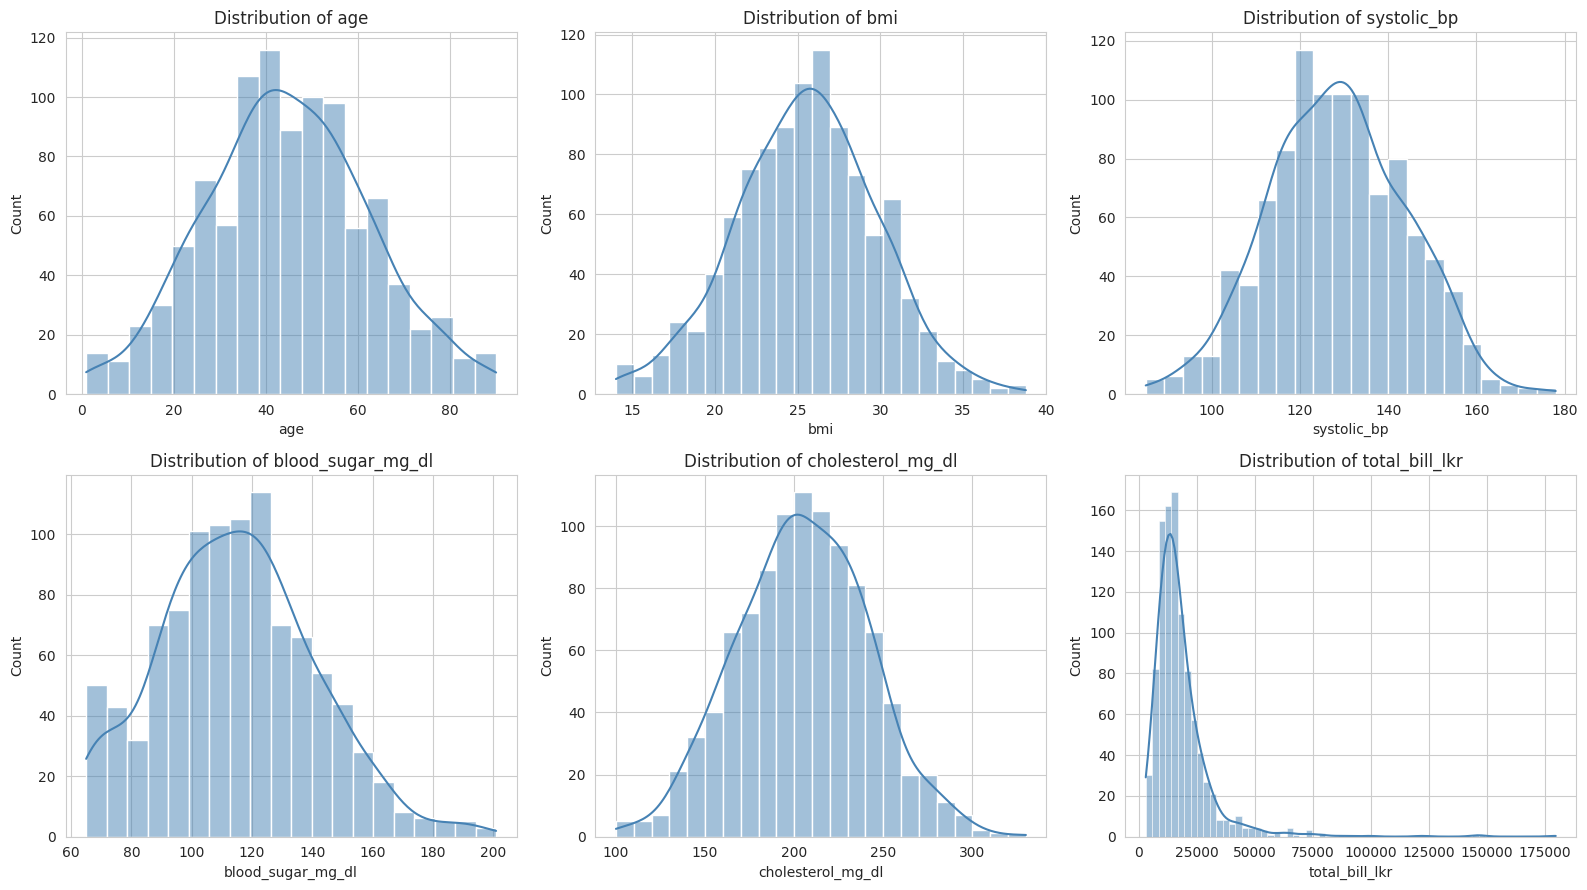

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, ['age','bmi','systolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl','total_bill_lkr']):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('eda_histograms_c.png', dpi=120)
plt.show()

/tmp/ipykernel_715/1345982756.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_risk_level', y=col, data=df_clean, ax=ax, order=order, palette='Set2')
/tmp/ipykernel_715/1345982756.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_risk_level', y=col, data=df_clean, ax=ax, order=order, palette='Set2')
/tmp/ipykernel_715/1345982756.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_risk_level', y=col, data=df_clean, ax=ax, order=order, palette='Set2')


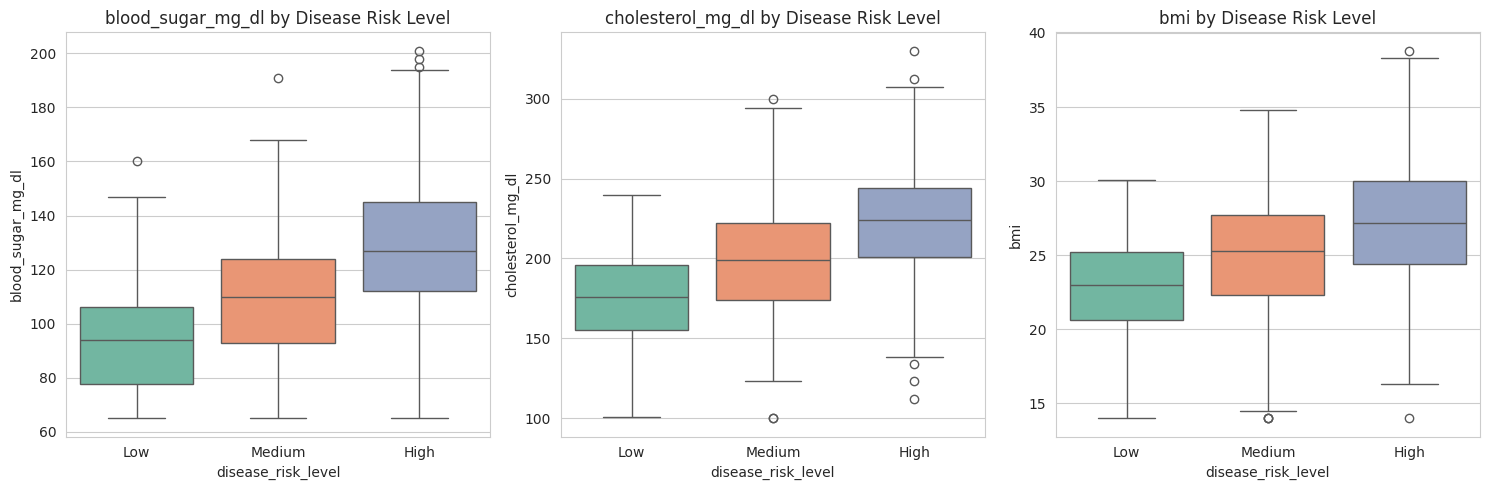

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
order = ['Low','Medium','High']
for ax, col in zip(axes, ['blood_sugar_mg_dl','cholesterol_mg_dl','bmi']):
    sns.boxplot(x='disease_risk_level', y=col, data=df_clean, ax=ax, order=order, palette='Set2')
    ax.set_title(f'{col} by Disease Risk Level')
plt.tight_layout()
plt.savefig('eda_boxplots_c.png', dpi=120)
plt.show()

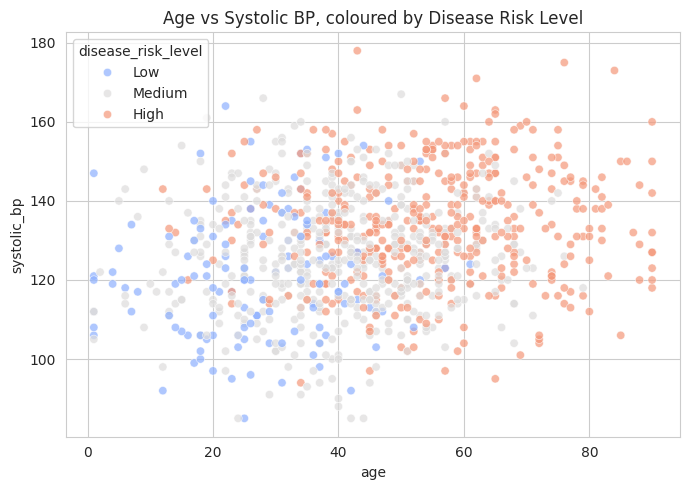

In [14]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df_clean, x='age', y='systolic_bp', hue='disease_risk_level',
                 hue_order=order, palette='coolwarm', ax=ax, alpha=0.7)
ax.set_title('Age vs Systolic BP, coloured by Disease Risk Level')
plt.tight_layout()
plt.savefig('eda_scatter_c.png', dpi=120)
plt.show()

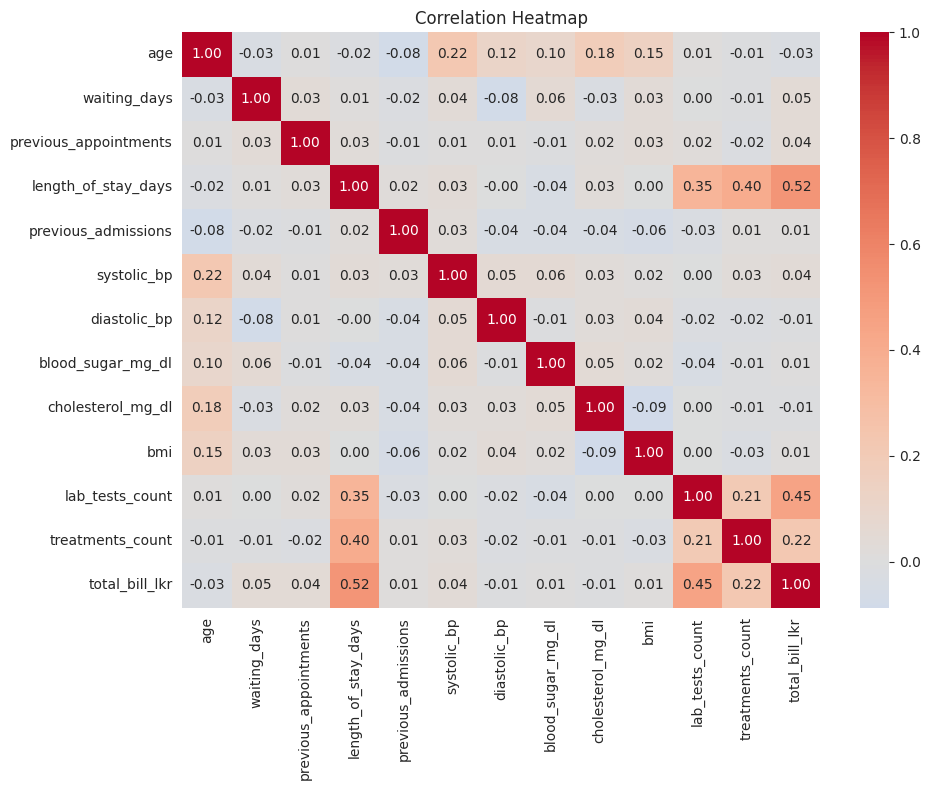

In [15]:
corr_cols = ['age','waiting_days','previous_appointments','length_of_stay_days',
             'previous_admissions','systolic_bp','diastolic_bp','blood_sugar_mg_dl',
             'cholesterol_mg_dl','bmi','lab_tests_count','treatments_count','total_bill_lkr']
plt.figure(figsize=(10,8))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_heatmap_c.png', dpi=120)
plt.show()

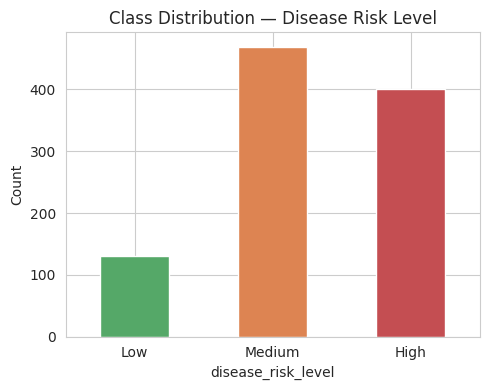

In [16]:
plt.figure(figsize=(5,4))
df_clean['disease_risk_level'].value_counts().reindex(order).plot(
    kind='bar', color=['#55A868','#DD8452','#C44E52'])
plt.xticks(rotation=0)
plt.title('Class Distribution — Disease Risk Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_class_balance_c.png', dpi=120)
plt.show()

### EDA Insights (expand with your own observations in the report)

- Target classes are moderately imbalanced: Medium (46.9%), High (40.0%), Low (13.1%) —
  Low is a clear minority class, which should inform metric choice (macro-averaged
  Precision/Recall/F1 over raw Accuracy) and modelling strategy (class weighting).
- Boxplots show a clear, monotonic increase in blood sugar, cholesterol, and BMI from
  Low → Medium → High risk — these are the clinically expected relationships and strong
  predictive signals.
- The scatterplot of age vs systolic BP shows High-risk patients cluster toward older age
  and higher BP, though with some overlap with Medium — expect some class confusion
  between Medium and High in the confusion matrix.
- Correlation heatmap shows clinical vitals are largely independent of each other,
  supporting their inclusion as diverse, non-redundant features.


---
# Task 05 — Machine Learning Model Development

We train three multi-class classification models: **Logistic Regression** (multinomial,
interpretable baseline), **Random Forest** (non-linear, robust to outliers), and
**XGBoost** (gradient boosting, native multi-class support). Given class imbalance
(Low = 13.1%), we use a stratified split and class weighting where supported.


In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")

Train: (800, 62), Test: (200, 62)
Train class balance:
disease_risk_level
1    0.469
2    0.400
0    0.131
Name: proportion, dtype: float64


In [18]:
models = {}

# Logistic Regression (scikit-learn auto-selects multinomial for multi-class targets)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = (lr, X_test_scaled)

# Random Forest
rf_params = {'n_estimators':[100,200], 'max_depth':[5,10,None]}
rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                        rf_params, cv=3, scoring='f1_macro')
rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)
models['Random Forest'] = (rf, X_test)

# XGBoost (native multi-class via objective='multi:softprob')
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                     objective='multi:softprob', num_class=3,
                     eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
models['XGBoost'] = (xgb, X_test)

print("\nAll three models trained.")

Best RF params: {'max_depth': 5, 'n_estimators': 200}



All three models trained.


---
# Task 06 — Model Evaluation

For multi-class classification, we report Accuracy, macro-averaged Precision/Recall/F1
(each class weighted equally regardless of size — appropriate given the Low-risk class is
a minority), and Confusion Matrices, as specified in the brief.


In [19]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

results = []
for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro Precision': precision_score(y_test, y_pred, average='macro'),
        'Macro Recall': recall_score(y_test, y_pred, average='macro'),
        'Macro F1 Score': f1_score(y_test, y_pred, average='macro'),
    })

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df

,Accuracy,Macro Precision,Macro Recall,Macro F1 Score
Model,,,,
Logistic Regression,0.910,0.922,0.886,0.902
Random Forest,0.815,0.802,0.814,0.808
XGBoost,0.810,0.832,0.766,0.790


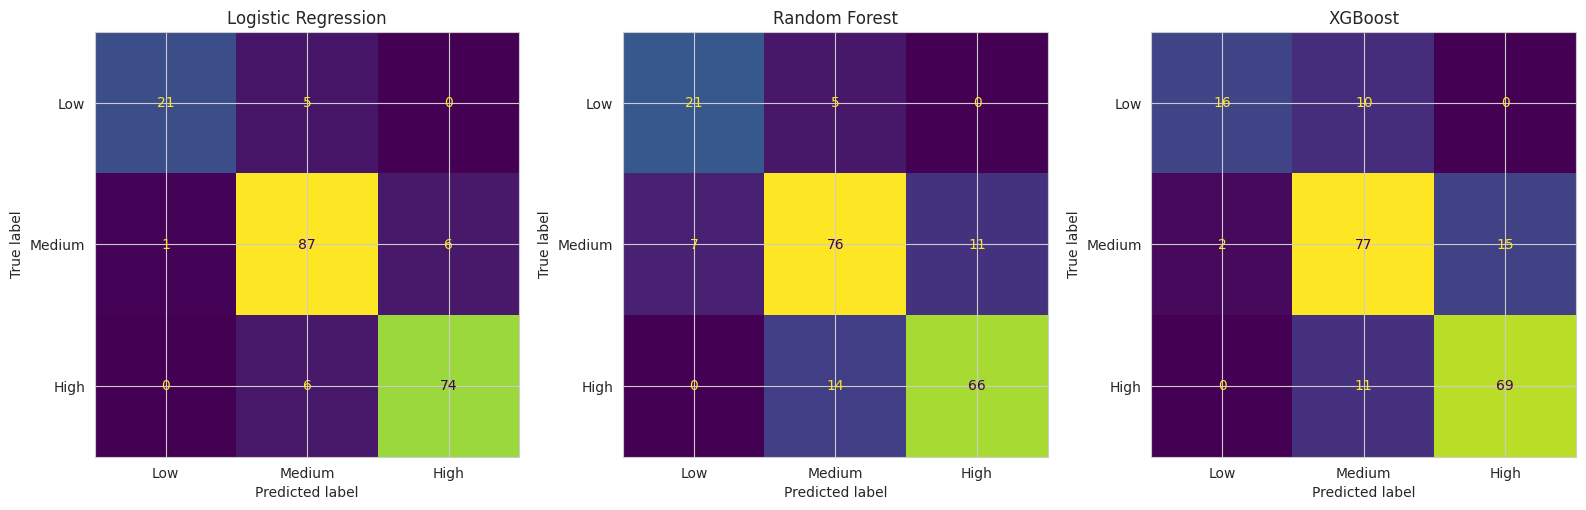

In [20]:
labels = [0,1,2]
label_names = ['Low','Medium','High']
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, (name, (model, X_te)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_te), labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig('confusion_matrices_c.png', dpi=120)
plt.show()

In [21]:
# Detailed per-class report for the best model (by macro F1)
best_name = results_df['Macro F1 Score'].idxmax()
best_model, best_Xte = models[best_name]
print(f"Best model by Macro F1: {best_name}\n")
print(classification_report(y_test, best_model.predict(best_Xte), target_names=label_names))

Best model by Macro F1: Logistic Regression

              precision    recall  f1-score   support

         Low       0.95      0.81      0.88        26
      Medium       0.89      0.93      0.91        94
        High       0.93      0.93      0.93        80

    accuracy                           0.91       200
   macro avg       0.92      0.89      0.90       200
weighted avg       0.91      0.91      0.91       200



### Best Model Justification

With three imbalanced classes, macro-averaged F1 is preferred over accuracy, since accuracy
can be dominated by the two larger classes (Medium, High) while masking poor performance on
the minority Low-risk class — which is clinically important to catch correctly (misclassifying
a Low-risk patient as High risk wastes resources; misclassifying High as Low risks missed
intervention). Review the per-class report above and write 2-3 sentences here naming your
best model and specifically how it performs on the Low-risk class — this is exactly the kind
of detail the viva will probe.


---
# Task 07 — Explainable AI Analysis (SHAP)

We use SHAP on the XGBoost model to interpret which features drive disease risk
classification, for each of the three risk classes.


In [22]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# TreeExplainer returns shape (n_samples, n_features, n_classes) for multi-class XGBoost
sv = np.array(shap_values)
print("SHAP values shape:", sv.shape)

SHAP values shape: (200, 62, 3)


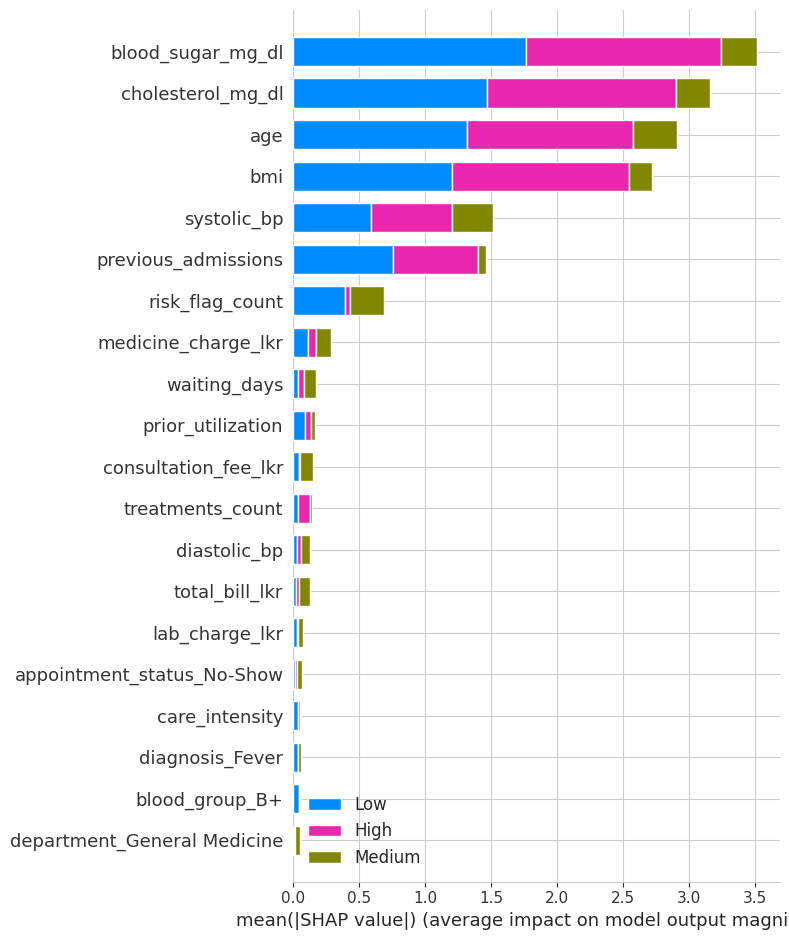

In [23]:
# Multi-class summary plot requires a LIST of 2D arrays (one per class), not the raw 3D array
sv_list = [sv[:,:,i] for i in range(sv.shape[2])]
shap.summary_plot(sv_list, X_test, class_names=label_names, show=False)
plt.tight_layout()
plt.savefig('shap_summary_c.png', dpi=120, bbox_inches='tight')
plt.show()

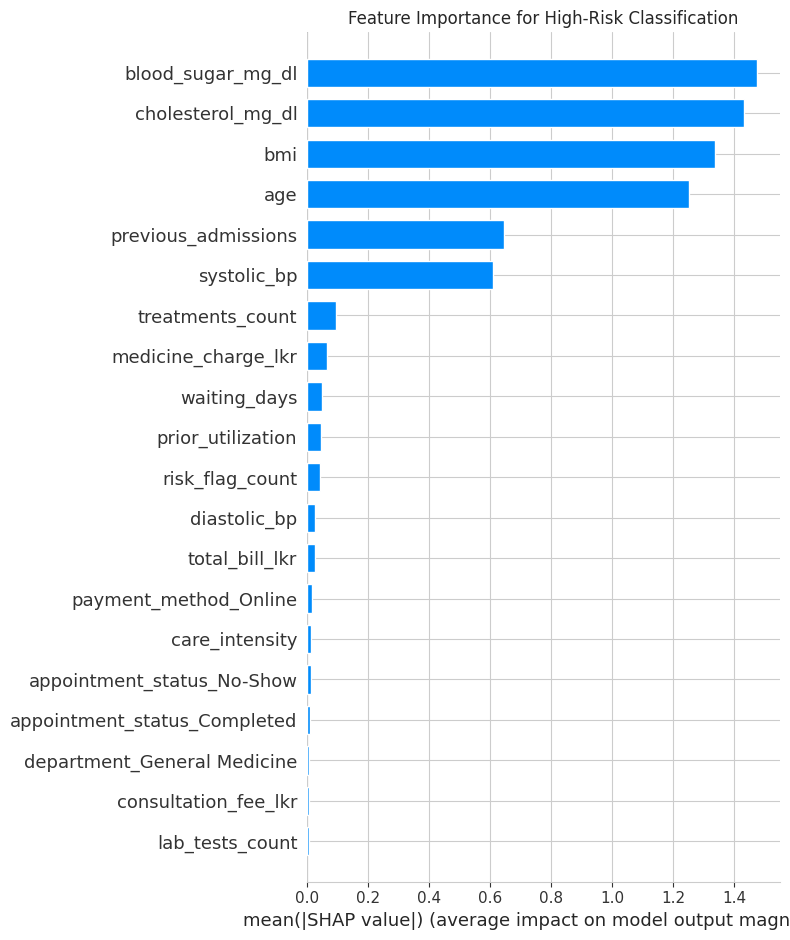

In [24]:
# Feature importance for the High-risk class specifically (class index 2)
high_risk_idx = 2
shap.summary_plot(sv[:,:,high_risk_idx], X_test, plot_type='bar', show=False)
plt.title('Feature Importance for High-Risk Classification')
plt.tight_layout()
plt.savefig('shap_importance_bar_c.png', dpi=120, bbox_inches='tight')
plt.show()

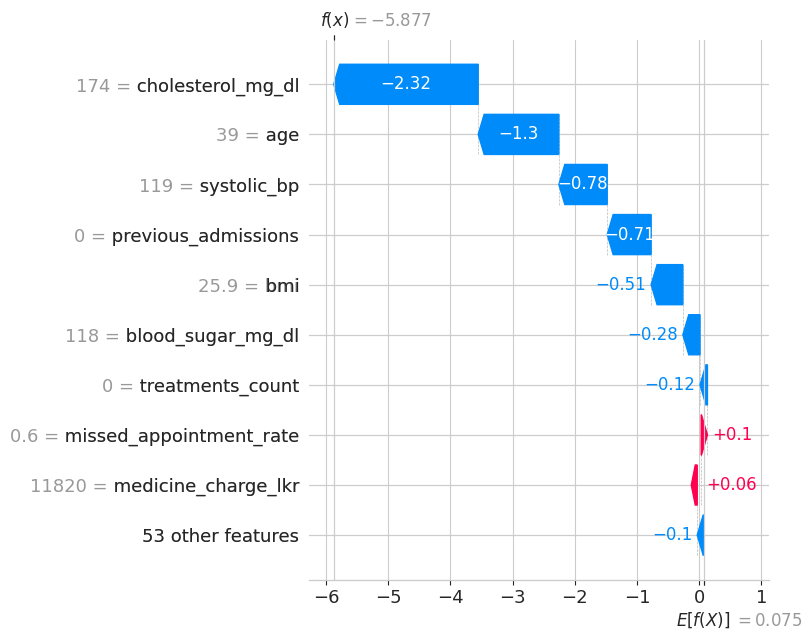

In [25]:
# Individual prediction explanation for one patient, High-risk class
idx = 0
sv_patient = sv[idx][:, high_risk_idx]
base = explainer.expected_value[high_risk_idx] if hasattr(explainer.expected_value,'__len__') else explainer.expected_value
exp = shap.Explanation(values=sv_patient, base_values=base,
                        data=X_test.iloc[idx], feature_names=X_test.columns.tolist())
shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.savefig('shap_waterfall_example_c.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretation, Transparency & Ethics (expand in your report)

- **Important features:** identify the top features from the bar chart driving High-risk
  classification specifically — expect clinical vitals (blood sugar, cholesterol, BP, BMI)
  to dominate, consistent with the EDA in Task 04.
- **Prediction reasoning:** use the waterfall plot to explain one patient's High-risk
  classification — which features pushed that specific prediction up vs down.
- **Transparency:** per-class SHAP values let clinicians see *why* a patient was placed in
  a specific risk tier, not just which tier — useful for triage prioritisation.
- **Ethical implications:** check whether `age` ranks highly (it likely will, given the EDA
  trend of High-risk skewing older) — discuss whether this reflects genuine clinical risk
  or could unfairly disadvantage older patients in triage prioritisation if used without
  clinical oversight. Check `gender` importance too, and discuss any imbalance found.


In [26]:
import joblib
joblib.dump(xgb, 'best_model_xgboost_optionC.pkl')
joblib.dump(scaler, 'scaler_optionC.pkl')
joblib.dump(list(X.columns), 'feature_columns_optionC.pkl')
joblib.dump({'bmi_order':bmi_order,'age_order':age_order,'risk_order':risk_order},
            'encoding_maps_optionC.pkl')
print("Model and preprocessing artifacts saved.")

Model and preprocessing artifacts saved.
